In [1]:
'''TODO EARLY STOPPING, SELF/CROSS ATTENTION IN AUTO ENCODER, BLOCKING ON ALGS OR PASSWORDS OR SOURCES, REGULARIZATION ON LAYERS AND/OR SEPERATE NORMALIZATION LAYERS'''
'''potentially add stuff for tau statistics (scipy function avalible) and actually do the lil histograms and stuff'''
'''TODO add fancier plots for comparing and the training history of the models'''
from ollama import chat
from ollama import ChatResponse
import secrets
from Crypto.Cipher import AES
from sklearn.cluster import SpectralClustering
from sklearn.model_selection import train_test_split
from Crypto.Cipher import AES
from Crypto.Hash import SHAKE128
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D, Attention, Normalization, Reshape, Conv2DTranspose, MultiHeadAttention, BatchNormalization, Activation
import polars as pl
import os
from Crypto.Util.Padding import pad, unpad
import math
from keras import Model, Input, Sequential
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import plotly.express as px
from keras.callbacks import EarlyStopping
import plotly.graph_objects as go
from scipy.stats import kendalltau
from random import randint
import copy
from plotly.subplots import make_subplots

2025-04-20 15:36:43.319417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-20 15:36:43.335506: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-20 15:36:43.340176: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-20 15:36:43.351897: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


I0000 00:00:1745185005.432546   73749 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745185005.474645   73749 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745185005.474845   73749 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [3]:
'''Passwords & Hashes'''
passwords = [b"Andromeda", b"Neptune", b"Jupiter", b"Saturn"]
algs= ['128', '256'] #be sure to add 512 eventually
hash128 = {password: SHAKE128.new(password).read(128 // 8) for password in passwords}
hash256 = {password: SHAKE128.new(password).read(256 // 8) for password in passwords}
hash512 = {password: SHAKE128.new(password).read(512 // 8) for password in passwords}
print(hash512[b'Andromeda'])
print(hash128)

b"p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00%\xf0R\xf73NF\xb3\x86\xd2\x9dJ\x84\x9b(^\x8c\xc3a\x93\xf2\xca\xc6\xafI\xaf\x93\x1f\xe6\x8d\x05)\xb5\xa1\x08\x86X\x02\xc9'\x07\x84\xf3bl\\\x99f"
{b'Andromeda': b'p\x17Y{\xbc\x82\x06\xb7\tr\xd7\xeb)~\xf4\x00', b'Neptune': b'\xe3\xbc\xf4\x89\xd6\x13I4\xe9\x08&\xfd\xe2a[#', b'Jupiter': b'/Z\xd0\xd26\x95\x9b\xe5u\x9bs\xbcub-\x86', b'Saturn': b'L4 \xab\x95\n\xb2\xffM\x14O-\xf1\xe2a\x14'}


In [4]:
def encrypt_portion(password, plaintext):
    ciphertext = AES.new(password, AES.MODE_CBC).encrypt(pad(plaintext, 512 // 8, 'iso7816'))
    return ciphertext

In [ ]:
def plot_training(history):
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Loss", "Accuracy"))
    # Plot Loss
    epochs = [x for x in range(len(history['loss']))]
    fig.add_trace(go.Scatter(
        x=epochs, y=history['loss'],
        mode='lines+markers', name='Training Loss',
        line=dict(color='royalblue')
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=epochs, y=history['val_loss'],
        mode='lines+markers', name='Validation Loss',
        line=dict(color='lightblue')
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=epochs, y=history['accuracy'],
        mode='lines+markers', name='Training Accuracy',
        line=dict(color='seagreen')
    ), row=1, col=2)

    fig.add_trace(go.Scatter(
        x=epochs, y=history['val_accuracy'],
        mode='lines+markers', name='Validation Accuracy',
        line=dict(color='lightgreen')
    ), row=1, col=2)

    fig.update_layout(
        title_text="Training History",
        xaxis_title="Epoch",
        yaxis_title="Loss/Accuracy",
        height=500,
        width=900,
        legend=dict(x=0.5, y=-0.2, orientation="h", xanchor="center"),
        margin=dict(t=50, b=100)
    )
    return fig

In [6]:
'''Encrypt Messages'''
'''need all ciphertexts to be the same size, maybe just set a block limit based on the shortest message length?'''
'''add a variable for blocks per data point, could prolly start with three so we get a lot more data'''
'''do i need to do a password prediction variant where it actually tries to predict the password value as oppossed to the numeric label'''
'''give it a worl'''
#should only need to be done once
def encryptMessages(size, pass_dict, max_blocks, blocks_per_point):
    max_bytes = (max_blocks * 512) // 8 #should be a perfect division anyways
    byte_range_len = (blocks_per_point * 512) // 8
    points_per_file = max_bytes // byte_range_len
    passwords = list(pass_dict.keys())
    for (root, dirs, files) in os.walk("../HumanReadable"):
        for file in files:
            with open(f'../HumanReadable/{file}', 'rb') as plaintextstore:
                plaintext = plaintextstore.read()
                for byte_range in range(points_per_file):
                    for password in passwords:
                        #print(len(pass_dict[password]))
                        with open(f'../{size}ciphertext/{size}_{password}_{file}_{byte_range}', 'wb') as cipherstore:
                            #ciphertext = AES.new(pass_dict[password], AES.MODE_ECB).encrypt(pad(plaintext[byte_range * byte_range_len:(byte_range+1)*byte_range_len], 512, 'iso7816'))
                            plaintext_portion = plaintext[byte_range * byte_range_len:(byte_range+1)*byte_range_len]
                            if len(plaintext_portion) != 192:
                                print(len(plaintext_portion))
                            ciphertext = encrypt_portion(pass_dict[password], plaintext_portion)
                            if len(ciphertext) != 256:
                                print(len(ciphertext))
                            cipherstore.write(ciphertext)
#not most blocks present but most blocks to use = num blocks in shortest message
max_blocks = 1000
image_shape = [8, 8]
for (root, dirs, files) in os.walk("../HumanReadable"):
    for file in files:
        with open(f'../HumanReadable/{file}', 'rb') as plaintextstore:
            plaintext = plaintextstore.read()
            if math.floor((len(plaintext) * 8) / 512) < max_blocks:
                max_blocks = math.floor((len(plaintext) * 8) / 512)
blocks_per_point = 3
print(math.sqrt((512 * blocks_per_point) / 8))
img_size = (512 * blocks_per_point) // 8 + (512 // 8) #need to add the extra padding
s = math.floor(math.sqrt(img_size))
l = s
w = s
r = img_size - (l*w)
while r != 0:
    l -= 1
    w = math.floor(img_size / l)
    r = img_size - (l*w)
image_shape = [l,w]
image_shape.append(1)
image_shape = tuple(image_shape)
print(blocks_per_point, image_shape)
assert(image_shape[0] * image_shape[1] == (512 * blocks_per_point) / 8 + 64)
encryptMessages('128', hash128, max_blocks, blocks_per_point)
encryptMessages('256', hash256, max_blocks, blocks_per_point)

13.856406460551018
3 (16, 16, 1)


In [7]:
'''Compile Training Data'''
columns = ['alg', 'password', 'source_file', 'plaintext', 'ciphertext']
data = []
#image size is greater than plaintext ize due to padding an extra block
max_bytes = (max_blocks * 512) // 8
byte_range_len = (blocks_per_point * 512) // 8
points_per_file = math.floor(max_bytes / byte_range_len)
for alg in algs:
    for password in passwords:
        for (root, dirs, files) in os.walk("../HumanReadable"):
            for source_file in files:
                for byte_range in range(points_per_file):
                    with open(f'../HumanReadable/{source_file}', 'rb') as plaintextstore:
                        plaintext = plaintextstore.read()
                        with open(f'../{alg}ciphertext/{alg}_{password}_{source_file}_{byte_range}', 'rb') as cipherstore:
                            ciphertext = cipherstore.read()
                            #print(len(ciphertext))
                            #normalize and want (l,w,d) shape
                            #print(len(ciphertext))
                            assert(len(ciphertext) == img_size)
                            ciphertextimage = [[[int(byte)/255] for byte in ciphertext[row*image_shape[0] : row*image_shape[0] + image_shape[1]]] for row in range(image_shape[0])]
                            assert(len(ciphertextimage) == image_shape[0])
                            assert(len(ciphertextimage[0]) == image_shape[1])
                            assert(len(ciphertextimage[0][0]) == image_shape[2])
                            #ciphertextimagearray = np.asarray(ciphertextimage, np.float32)
                            plaintext_portion = plaintext[byte_range_len*byte_range:(byte_range+1)*byte_range_len]
                            #plaintextimage = [[[int(byte)/255] for byte in plaintext_portion[row*image_shape[0] : row*image_shape[0] + image_shape[1]]] for row in range(image_shape[0])]
                            #plaintextimagearray = np.asarray(plaintextimage, np.float32)
                            #entire ciphertext file is valid but must split plaintext
                            #make sure to fill in leading zeros
                            #plaintext_bits = [list(bin(int(byte))[2:].zfill(8)) for byte in plaintext_portion]
                            #ciphertext_bits = [list(bin(int(byte))[2:].zfill(8)) for byte in ciphertext]
                            data.append([alg, password, source_file + f'_{byte_range}', plaintext_portion, ciphertextimage])

df = pl.LazyFrame(data, columns, orient='row')
df = df.collect()
df = df.sample(fraction=1, shuffle= True)
#df = df.to_dummies(columns[:-2])
train_size = math.floor( .9 * len(df))
test_size = len(df) - train_size
train, test = df.head(train_size), df.tail(test_size)
train_data, test_data = train['ciphertext'], test['ciphertext']
train_targets, test_targets = train.select(pl.exclude('ciphertext')), test.select(pl.exclude('ciphertext'))

In [8]:
print(df)

shape: (19_200, 5)
┌─────┬──────────────┬───────────────────┬────────────────────────────┬────────────────────────────┐
│ alg ┆ password     ┆ source_file       ┆ plaintext                  ┆ ciphertext                 │
│ --- ┆ ---          ┆ ---               ┆ ---                        ┆ ---                        │
│ str ┆ binary       ┆ str               ┆ binary                     ┆ list[list[list[f64]]]      │
╞═════╪══════════════╪═══════════════════╪════════════════════════════╪════════════════════════════╡
│ 256 ┆ b"Jupiter"   ┆ Convo28Message1_5 ┆ b"\x20a\x20weak\x20point\x ┆ [[[0.094118], [0.462745],  │
│     ┆              ┆                   ┆ 20in…                      ┆ … [0…                      │
│ 128 ┆ b"Andromeda" ┆ Convo8Message3_2  ┆ b"ything.\x20Authorization ┆ [[[0.788235], [0.235294],  │
│     ┆              ┆                   ┆ \x20…                      ┆ … [0…                      │
│ 128 ┆ b"Neptune"   ┆ Convo20Message1_7 ┆ b"\xe2\x80\x99s\x20output\ ┆ 

In [9]:
for x in train_data.to_list():
    if len(x) != image_shape[0]:
        print('1st',x)
    for y in x:
        if len(y) != image_shape[1]:
            print('2nd', y)
        for z in y:
            if len(z) != image_shape[2]:
                print('3rd', z)

In [10]:
train_data_format = np.array(train_data.to_list())
test_data_format = np.array(test_data.to_list())
sources = df['source_file'].unique()
print(sources)

shape: (2_400,)
Series: 'source_file' [str]
[
	"Convo34Message2_8"
	"Convo17Message4_11"
	"Convo20Message0_8"
	"Convo29Message2_0"
	"Convo24Message0_9"
	…
	"Convo8Message4_11"
	"Convo36Message2_10"
	"Convo11Message4_1"
	"Convo4Message0_8"
	"Convo28Message0_1"
]


In [11]:
def make_mapping(data, enum_vals, col_name):
    mapping = {enum_val: i for i, enum_val in enumerate(enum_vals)}
    mapped_data = data.with_columns(
    pl.col(col_name).replace_strict(mapping)
    )
    return mapped_data, mapping

In [12]:
print(train_targets.head())

shape: (5, 4)
┌─────┬──────────────┬───────────────────┬─────────────────────────────────┐
│ alg ┆ password     ┆ source_file       ┆ plaintext                       │
│ --- ┆ ---          ┆ ---               ┆ ---                             │
│ str ┆ binary       ┆ str               ┆ binary                          │
╞═════╪══════════════╪═══════════════════╪═════════════════════════════════╡
│ 256 ┆ b"Jupiter"   ┆ Convo28Message1_5 ┆ b"\x20a\x20weak\x20point\x20in… │
│ 128 ┆ b"Andromeda" ┆ Convo8Message3_2  ┆ b"ything.\x20Authorization\x20… │
│ 128 ┆ b"Neptune"   ┆ Convo20Message1_7 ┆ b"\xe2\x80\x99s\x20output\x20m… │
│ 256 ┆ b"Andromeda" ┆ Convo38Message3_4 ┆ b"to\x20the\x20Weaver\xe2\x80\… │
│ 128 ┆ b"Andromeda" ┆ Convo6Message1_0  ┆ b"Subject:\x20Nightingale\x20-… │
└─────┴──────────────┴───────────────────┴─────────────────────────────────┘


In [13]:
'''Autoencoder'''
'''normalization before attention, batch normalization before convolution'''
'''CNN -> batchnormalize -> activation -> dropout'''
'''normalization -> attention -> dropout'''
#is mean pooling worth investigating
#will need to play around with amount of parameters
#should i include more than just the ciphertext?
encoder_input = Input(shape=image_shape)
#4x4 byte matrix is AES operator size seems fitting
#blocks*4 is the amount of AES-128 blocks which seems like a decent starting metric
encoder = Conv2D(max_blocks*4, (4,4), padding='same')(encoder_input)
encoder = BatchNormalization(axis=-1)(encoder)
encoder = Activation('relu')(encoder)
encoder = Dropout(.5)(encoder)
encoder = MaxPool2D(pool_size=(4,4), strides=4)(encoder)
encoder = BatchNormalization(axis=-1)(encoder)

encoder = Conv2D(max_blocks, (4,4), padding='same', activation='relu')(encoder)
encoder = BatchNormalization(axis=-1)(encoder)
encoder = Activation('relu')(encoder)
encoder = Dropout(.5)(encoder)
encoder = MaxPool2D(pool_size=(2,2), strides=4)(encoder)
encoder_attended = Normalization(axis = -1)(encoder)
'''maybe try cross attention?'''
encoder_attention = MultiHeadAttention(num_heads=4, key_dim=16)(encoder_attended, encoder_attended)
encoder = Dropout(.5)(encoder_attention)
encoder = Flatten()(encoder)
embedded_layer = Dense(3, activation='relu')(encoder)
decoder1 = Dense(4, activation='relu')(embedded_layer)
decoder2 = Reshape((2,2,1))(decoder1)
decoder3 = Conv2DTranspose(max_blocks, (2,2), strides = (l // 2,w // 2), padding='same', activation='relu')(decoder2)
#decoder3 = Conv2DTranspose(max_blocks * 4, (2,2), strides = (l // 2,w // 2), padding='same', activation='relu')(decoder2)
decoder4 = Conv2D(1, (4, 4), activation="sigmoid", padding="same")(decoder3)

autoencoder = Model(encoder_input, decoder4)
encoder = Model(encoder_input, embedded_layer)


I0000 00:00:1745185045.449958   73749 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745185045.450413   73749 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745185045.450568   73749 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745185045.531155   73749 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [14]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 16, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │      2,584 │ input_layer[0][0] │
│                     │ 152)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 16,    │        608 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 152)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 152)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ activation[0][0]  │
│                     │ 152)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 4, 4, 152) │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 152) │        608 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 4, 4, 38)  │     92,454 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 38)  │        152 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 4, 4, 38)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 4, 4, 38)  │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 1, 1, 38)  │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 1, 1, 38)  │         77 │ max_pooling2d_1[… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 1, 38)  │      9,958 │ normalization[0]… │
│ (MultiHeadAttentio… │                   │            │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1, 1, 38)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 38)        │          0 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3)         │        117 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │         16 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 2, 2, 1)   │          0 │ dense_1[0][0]   

 Total params: 107,373 (419.43 KB)

 Trainable params: 106,612 (416.45 KB)

 Non-trainable params: 761 (2.98 KB)

In [17]:
'''keras example uses binary_crossentropy but they also had binary images, description says its for binary classification though'''
'''mse as alternate'''
autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
autoencoder_callback = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
encoder_hist = autoencoder.fit(train_data_format, train_data_format, epochs = 200, callbacks=[autoencoder_callback], validation_split=.1)

Epoch 1/200
486/486 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0042 - loss: 0.6914 - val_accuracy: 0.0040 - val_loss: 0.6924
Epoch 2/200
486/486 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0041 - loss: 0.6914 - val_accuracy: 0.0041 - val_loss: 0.6923
Epoch 3/200
486/486 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0041 - loss: 0.6914 - val_accuracy: 0.0042 - val_loss: 0.6923
Epoch 4/200
486/486 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0041 - loss: 0.6914 - val_accuracy: 0.0040 - val_loss: 0.6922
Epoch 5/200
486/486 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0042 - loss: 0.6914 - val_accuracy: 0.0042 - val_loss: 0.6922
Epoch 6/200
486/486 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0041 - loss: 0.6914 - val_accuracy: 0.0041 - val_loss: 0.6922
Epoch 7/200
486/486 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0041 - loss: 0.6914 - val_accuracy: 0.0041 - val_loss: 0.6922
Epoch 8/200
486/486 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0041 - loss: 0.6915 - val_accu

In [18]:
encoder_plot = plot_training(encoder_hist.history)
encoder_plot.show()

In [19]:
autoencoder_results = autoencoder.evaluate(test_data_format, test_data_format)
print(autoencoder_results)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0044 - loss: 0.6922
[0.6921653747558594, 0.0043009440414607525]


In [20]:
encode = encoder.predict(test_data_format)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [21]:
len(train_data.to_list())

17280

In [22]:
'''Supervised Classification'''
activation = ''
if len(algs) == 2:
    activation = 'sigmoid'
else:
    activation = 'softmax'
# encoder_input = Input(shape=image_shape)
# algclass1 = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')
# alg_drop1 = Dropout(.3)
# algclass2 = MaxPool2D(pool_size=(4,4), strides=4)
# algclass3 = Conv2D(max_blocks, (4,4), padding='same', activation='relu')
# alg_drop2 = Dropout(.3)
# algclass4 = MaxPool2D(pool_size=(4,4), strides=4)
# algclass5 = Flatten()
# alg_prediction_layer = Dense(len(algs), activation=activation)
# alg_classifier = Sequential([encoder_input, algclass1, alg_drop1, algclass2, algclass3, alg_drop2, algclass4, algclass5, alg_prediction_layer])
'''had to change strides so not quite original intuition'''
alg_heads = 4
alg_key_dim =16
alg_atten_dim = alg_heads*alg_key_dim
alg_input = Input(shape=image_shape)
alg_classifier = Conv2D(blocks_per_point*4, (4,4), padding='same')(alg_input)
alg_classifier = BatchNormalization(axis = -1)(alg_classifier)
alg_classifier = Activation('relu')(alg_classifier)
alg_classifier = Dropout(.5)(alg_classifier)
alg_classifier = MaxPool2D(pool_size=(4,4), strides=2)(alg_classifier)
alg_classifier = BatchNormalization(axis = -1)(alg_classifier)
alg_classifier = Conv2D(blocks_per_point, (4,4), padding='same')(alg_classifier)
alg_classifier = BatchNormalization(axis = -1)(alg_classifier)
alg_classifier = Activation('relu')(alg_classifier)
alg_classifier = Dropout(.5)(alg_classifier)
alg_classifier = MaxPool2D(pool_size=(4,4), strides=2)(alg_classifier)
alg_classifier = BatchNormalization(axis = -1)(alg_classifier)
alg_classifier = Conv2D(alg_atten_dim, kernel_size=1)(alg_classifier)
alg_classifier = Reshape((-1, alg_atten_dim))(alg_classifier)
alg_classifier_attended = Normalization(axis = -1)(alg_classifier)
alg_classifier_attention = MultiHeadAttention(num_heads=alg_heads, key_dim=alg_key_dim)(alg_classifier_attended, alg_classifier_attended)
alg_classifier = Dropout(.5)(alg_classifier_attention)
alg_classifier = Flatten()(alg_classifier)
alg_classifier = Dense(len(algs), activation=activation)(alg_classifier)
alg_classifier = Model(alg_input, alg_classifier)

In [23]:
alg_classifier.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 16, 16, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │        204 │ input_layer_1[0]… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         48 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16, 16,    │          0 │ activation_2[0][… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 7, 7, 12)  │          0 │ dropout_4[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 12)  │         48 │ max_pooling2d_2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 3)   │        579 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 3)   │         12 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 7, 7, 3)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 7, 7, 3)   │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 2, 2, 3)   │          0 │ dropout_5[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 2, 3)   │         12 │ max_pooling2d_3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 2, 2, 64)  │        256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 4, 64)     │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 4, 64)     │        129 │ reshape_1[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4, 64)     │     16,640 │ normalization_1[… │
│ (MultiHeadAttentio… │                   │            │ normalization_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 4, 64)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 18,442 (72.04 KB)

 Trainable params: 18,253 (71.30 KB)

 Non-trainable params: 189 (760.00 B)

In [26]:
#use sparse categorical entropy for loss function i think
#may need to resize?
enum_alg_targets, alg_mapping = make_mapping(train_targets, algs, 'alg')
print(enum_alg_targets)
alg_callback = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
alg_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
alg_hist = alg_classifier.fit(train_data_format, enum_alg_targets['alg'].to_numpy(), epochs=200, callbacks=[alg_callback], validation_split=.1)

shape: (17_280, 4)
┌─────┬──────────────┬───────────────────┬─────────────────────────────────┐
│ alg ┆ password     ┆ source_file       ┆ plaintext                       │
│ --- ┆ ---          ┆ ---               ┆ ---                             │
│ i64 ┆ binary       ┆ str               ┆ binary                          │
╞═════╪══════════════╪═══════════════════╪═════════════════════════════════╡
│ 1   ┆ b"Jupiter"   ┆ Convo28Message1_5 ┆ b"\x20a\x20weak\x20point\x20in… │
│ 0   ┆ b"Andromeda" ┆ Convo8Message3_2  ┆ b"ything.\x20Authorization\x20… │
│ 0   ┆ b"Neptune"   ┆ Convo20Message1_7 ┆ b"\xe2\x80\x99s\x20output\x20m… │
│ 1   ┆ b"Andromeda" ┆ Convo38Message3_4 ┆ b"to\x20the\x20Weaver\xe2\x80\… │
│ 0   ┆ b"Andromeda" ┆ Convo6Message1_0  ┆ b"Subject:\x20Nightingale\x20-… │
│ …   ┆ …            ┆ …                 ┆ …                               │
│ 1   ┆ b"Neptune"   ┆ Convo17Message0_3 ┆ b"Panama,\x20funnelling\x20fun… │
│ 0   ┆ b"Saturn"    ┆ Convo34Message1_7 ┆ b"\x20to\x20th

In [27]:
print(alg_hist.history.keys())
alg_plot = plot_training(alg_hist.history)
alg_plot.show()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [28]:
print(len(test_data.to_list()))

1920


In [29]:
'''did I overfit on test data with hyperparameter tuning?'''
'''.3 did best but most recent result not as good as .4 for dropout rate'''
enum_alg_test_targets, alg_mapping = make_mapping(test_targets, algs, 'alg')
alg_results = alg_classifier.evaluate(np.array(test_data.to_list()), np.array(enum_alg_test_targets['alg'].to_list()))
print(alg_results)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4888 - loss: 0.6932
[0.6931542158126831, 0.5005208253860474]


In [30]:
'''Unsupervised Clustering'''
#make it more adaptive but rn 3 algs, 5 i think password, and some amount of plaintext
sc_algs = SpectralClustering(len(algs))
sc_pass = SpectralClustering(len(passwords))
sc_source = SpectralClustering(df['source_file'].n_unique())
array_input_train = np.array(df['ciphertext'].to_list())
flat_input_train = array_input_train.reshape(array_input_train.shape[0], -1)
print(flat_input_train)

[[0.09411765 0.4627451  0.45882353 ... 0.05882353 0.7254902  0.58039216]
 [0.78823529 0.23529412 0.00392157 ... 0.         0.63921569 0.59607843]
 [0.21960784 0.25882353 0.98823529 ... 0.40392157 0.31372549 0.71764706]
 ...
 [0.09803922 0.51764706 0.65882353 ... 0.37647059 0.29803922 0.90196078]
 [0.11764706 0.00784314 0.39607843 ... 0.12156863 0.30588235 0.98039216]
 [0.2745098  0.03137255 0.3372549  ... 0.45882353 0.35294118 0.45490196]]


In [31]:
'''check performance and then do with the encoded training data'''
#sc_alg_pred = sc_algs.fit_predict(flat_input_train)

'check performance and then do with the encoded training data'

In [32]:
#sc_pass_pred = sc_pass.fit_predict(flat_input_train)

In [33]:
'''probably too many groups for spectral'''
#sc_source = sc_source.fit_predict(flat_input_train)

'probably too many groups for spectral'

In [34]:
'''Supervised Confusion'''
#prolly same structure as alg classifier but with an output dimension to represent the amount of passwords
'''need to do one for each password maybe'''
'''could also just do it raw and see which algs get password guessed the most'''
'''try blocking and making a model per algorithm since the hashes are technically different and just compare performance'''
'''maybe just an avalanche analysis?'''
'''this could be where the histograms really pop off plus maybe the tau stuff'''
def make_pass_classifier():
    pass_heads = 4
    pass_key_dim =16
    pass_atten_dim = pass_heads*pass_key_dim
    pass_input = Input(shape=image_shape)
    pass_classifier = Conv2D(blocks_per_point*4, (4,4), padding='same')(pass_input)
    pass_classifier = BatchNormalization(axis = -1)(pass_classifier)
    pass_classifier = Activation('relu')(pass_classifier)
    pass_classifier = Dropout(.4)(pass_classifier)
    pass_classifier = MaxPool2D(pool_size=(4,4), strides=2)(pass_classifier)
    pass_classifier = BatchNormalization(axis = -1)(pass_classifier)
    pass_classifier = Conv2D(blocks_per_point, (4,4), padding='same')(pass_classifier)
    pass_classifier = BatchNormalization(axis = -1)(pass_classifier)
    pass_classifier = Activation('relu')(pass_classifier)
    pass_classifier = Dropout(.4)(pass_classifier)
    pass_classifier = MaxPool2D(pool_size=(4,4), strides=2)(pass_classifier)
    pass_classifier = BatchNormalization(axis = -1)(pass_classifier)
    pass_classifier = Conv2D(pass_atten_dim, kernel_size=1)(pass_classifier)
    pass_classifier = Reshape((-1, pass_atten_dim))(pass_classifier)
    pass_classifier_attended = Normalization(axis = -1)(pass_classifier)
    pass_classifier_attention = MultiHeadAttention(num_heads=pass_heads, key_dim=pass_key_dim)(pass_classifier_attended, pass_classifier_attended)
    pass_classifier = Dropout(.4)(pass_classifier_attention)
    pass_classifier = Flatten()(pass_classifier)
    pass_classifier = Dense(len(passwords), activation='softmax')(pass_classifier)
    pass_classifier = Model(pass_input, pass_classifier)
    return pass_classifier
pass_classifier128 = make_pass_classifier()
pass_classifier256 = make_pass_classifier()

In [35]:
def make_pass_data(df_original, alg_label):
    df = df_original.filter(pl.col('alg') == alg_label)
    train_size = math.floor( .9 * len(df))
    test_size = len(df) - train_size
    train, test = df.head(train_size), df.tail(test_size)
    train_data, test_data = train['ciphertext'], test['ciphertext']
    train_targets, test_targets = train.select(pl.exclude('ciphertext')), test.select(pl.exclude('ciphertext'))
    train_data_format = np.array(train_data.to_list())
    test_data_format = np.array(test_data.to_list())
    return train_data_format, test_data_format, train_targets, test_targets

In [36]:
pass128_train_x, pass128_test_x, pass128_train_y, pass128_test_y = make_pass_data(df, '128')
#mapping doesnt rely on  data but the enumerated type list passed in so it should be the same for all passwords for each alg and train/test
enum_pass_targets128, pass_mapping = make_mapping(pass128_train_y, passwords, 'password')
pass_classifier128.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
pass_callback128 = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
pass_hist128 = pass_classifier128.fit(pass128_train_x, enum_pass_targets128['password'].to_numpy(), epochs=200, callbacks=[pass_callback128], validation_split=.1)

Epoch 1/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2560 - loss: 1.3916 - val_accuracy: 0.2373 - val_loss: 1.3942
Epoch 2/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2465 - loss: 1.3915 - val_accuracy: 0.2697 - val_loss: 1.3938
Epoch 3/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2515 - loss: 1.3897 - val_accuracy: 0.2407 - val_loss: 1.3983
Epoch 4/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2552 - loss: 1.3873 - val_accuracy: 0.2407 - val_loss: 1.3875
Epoch 5/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2543 - loss: 1.3874 - val_accuracy: 0.2697 - val_loss: 1.3874
Epoch 6/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2589 - loss: 1.3871 - val_accuracy: 0.2697 - val_loss: 1.3864
Epoch 7/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2583 - loss: 1.3867 - val_accuracy: 0.2384 - val_loss: 1.3898
Epoch 8/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2610 - loss: 1.3860 - val_accu

In [37]:
pass128_plot = plot_training(pass_hist128.history)
pass128_plot.show()

In [38]:
enum_pass_test_targets128, pass_mapping = make_mapping(pass128_test_y, passwords, 'password')
pass_results128 = pass_classifier128.evaluate(pass128_test_x, np.array(enum_pass_test_targets128['password'].to_list()))
print(pass_results128)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2428 - loss: 1.4003
[1.3925303220748901, 0.24895833432674408]


In [39]:
pass256_train_x, pass256_test_x, pass256_train_y, pass256_test_y = make_pass_data(df, '256')
#mapping doesnt rely on  data but the enumerated type list passed in so it should be the same for all passwords for each alg and train/test
enum_pass_targets256, pass_mapping = make_mapping(pass256_train_y, passwords, 'password')
pass_classifier256.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
pass_callback256 = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
pass_hist256 = pass_classifier256.fit(pass256_train_x, enum_pass_targets256['password'].to_numpy(), epochs=200, callbacks=[pass_callback256], validation_split=.1)

Epoch 1/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2474 - loss: 1.3929 - val_accuracy: 0.2384 - val_loss: 1.3949
Epoch 2/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2508 - loss: 1.3885 - val_accuracy: 0.2859 - val_loss: 1.3848
Epoch 3/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2576 - loss: 1.3886 - val_accuracy: 0.2720 - val_loss: 1.3821
Epoch 4/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2600 - loss: 1.3883 - val_accuracy: 0.2720 - val_loss: 1.3826
Epoch 5/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2435 - loss: 1.3881 - val_accuracy: 0.2743 - val_loss: 1.3868
Epoch 6/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2562 - loss: 1.3875 - val_accuracy: 0.2720 - val_loss: 1.3862
Epoch 7/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2601 - loss: 1.3876 - val_accuracy: 0.2720 - val_loss: 1.3872
Epoch 8/200
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2538 - loss: 1.3865 - val_accu

In [40]:
pass_256plot = plot_training(pass_hist256.history)
pass_256plot.show()

In [41]:
enum_pass_test_targets256, pass_mapping = make_mapping(pass256_test_y, passwords, 'password')
pass_results256 = pass_classifier256.evaluate(pass256_test_x, np.array(enum_pass_test_targets256['password'].to_list()))
print(pass_results256)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2366 - loss: 1.3870
[1.3870887756347656, 0.24687500298023224]


In [42]:
'''Supervised Diffusion'''
'''may need a different approach to diffusion'''
'''gonna get messed up when I shake up the dataset construction'''
'''could also benefit from uniformly generated files but let stick with human readable for now'''
#same as above but with respect to the amount of sources
# encoder_input = Input(shape=image_shape)
# sourceclass1 = Conv2D(max_blocks*4, (4,4), padding='same', activation='relu')
# source_drop1 = Dropout(.2)
# sourceclass2 = MaxPool2D(pool_size=(4,4), strides=4)
# sourceclass3 = Conv2D(max_blocks, (4,4), padding='same', activation='relu')
# source_drop2 = Dropout(.2)
# sourceclass4 = MaxPool2D(pool_size=(4,4), strides=4)
# sourceclass5 = Flatten()
# source_prediction_layer = Dense(df['source_file'].n_unique(), activation='softmax')
# source_classifier = Sequential([encoder_input, sourceclass1, source_drop1, sourceclass2, sourceclass3, source_drop2, 
#                              sourceclass4, sourceclass5, source_prediction_layer])
# source_heads = 4
# source_key_dim =16
# source_atten_dim = source_heads*source_key_dim
# source_input = Input(shape=image_shape)
# source_classifier = Conv2D(max_blocks*4, (4,4), padding='same')(source_input)
# source_classifier = BatchNormalization(axis = -1)(source_classifier)
# source_classifier = Activation('relu')(source_classifier)
# source_classifier = Dropout(.3)(source_classifier)
# source_classifier = MaxPool2D(pool_size=(4,4), strides=4)(source_classifier)
# source_classifier = BatchNormalization(axis = -1)(source_classifier)
# source_classifier = Conv2D(max_blocks, (4,4), padding='same')(source_classifier)
# source_classifier = BatchNormalization(axis = -1)(source_classifier)
# source_classifier = Activation('relu')(source_classifier)
# source_classifier = Dropout(.3)(source_classifier)
# source_classifier = MaxPool2D(pool_size=(4,4), strides=4)(source_classifier)
# source_classifier = BatchNormalization(axis = -1)(source_classifier)
# source_classifier = Conv2D(source_atten_dim, kernel_size=1)(source_classifier)
# source_classifier = Reshape((-1, source_atten_dim))(source_classifier)
# source_classifier_attended = Normalization(axis = -1)(source_classifier)
# source_classifier_attention = MultiHeadAttention(num_heads=source_heads, key_dim=source_key_dim)(source_classifier_attended, source_classifier_attended)
# source_classifier = Dropout(.2)(source_classifier_attention)
# source_classifier = Flatten()(source_classifier)
# source_classifier = Dense(df['source_file'].n_unique(), activation='softmax')(source_classifier)
# source_classifier = Model(source_input, source_classifier)


'could also benefit from uniformly generated files but let stick with human readable for now'

In [43]:
print(df)

shape: (19_200, 5)
┌─────┬──────────────┬───────────────────┬────────────────────────────┬────────────────────────────┐
│ alg ┆ password     ┆ source_file       ┆ plaintext                  ┆ ciphertext                 │
│ --- ┆ ---          ┆ ---               ┆ ---                        ┆ ---                        │
│ str ┆ binary       ┆ str               ┆ binary                     ┆ list[list[list[f64]]]      │
╞═════╪══════════════╪═══════════════════╪════════════════════════════╪════════════════════════════╡
│ 256 ┆ b"Jupiter"   ┆ Convo28Message1_5 ┆ b"\x20a\x20weak\x20point\x ┆ [[[0.094118], [0.462745],  │
│     ┆              ┆                   ┆ 20in…                      ┆ … [0…                      │
│ 128 ┆ b"Andromeda" ┆ Convo8Message3_2  ┆ b"ything.\x20Authorization ┆ [[[0.788235], [0.235294],  │
│     ┆              ┆                   ┆ \x20…                      ┆ … [0…                      │
│ 128 ┆ b"Neptune"   ┆ Convo20Message1_7 ┆ b"\xe2\x80\x99s\x20output\ ┆ 

In [44]:
'''just use bytes dont worry about characters'''
'''Skeleton&plots by GPT initially but later modified'''
'''STILL NEED AVALANCHE'''

def compute_stats(df: pl.DataFrame, alg: str):
    # Filter to a single algorithm
    df_alg = df.filter(pl.col("alg") == alg)

    # Convert normalized floats (0.0–1.0) back to byte integers (0–255)
    # df_alg = df_alg.with_columns([
    #     pl.col("plaintext").flatten().flatten().list.eval((pl.element()*255).cast(pl.UInt8), parallel=True).alias('p_bytes'),
    #     pl.col("ciphertext").flatten().flatten().list.eval((pl.element()*255).cast(pl.UInt8), parallel=True).alias('c_bytes')
    # ])
    '''plaintext is now original byte string'''
    df_p = df_alg.select(
        pl.col('plaintext').map_elements(lambda x: list(x)).explode().alias('byte')
    )

    df_c = df_alg.select(
        pl.col("ciphertext").flatten().flatten().list.eval((pl.element()*255).cast(pl.UInt8), parallel=True).explode().alias('byte')
    )


    # Frequency count of each byte value (0–255)
    p_freq = df_p.group_by("byte").len(name = 'p_count')
    c_freq = df_c.group_by("byte").len(name = 'c_count')
    #print(p_freq)
    #print(c_freq)

    full_bytes = pl.DataFrame({'byte': list(range(256))}).with_columns(pl.col("byte").cast(pl.UInt8))

    p_freq = full_bytes.join(
        df_p.group_by("byte").len().rename({"len": "p_count"}),
        on="byte",
        how="left"
    ).fill_null(0)

    c_freq = full_bytes.join(
        df_c.group_by("byte").len().rename({"len": "c_count"}),
        on="byte",
        how="left"
    ).fill_null(0)


    # Merge PT and CT frequencies, filling in 0 for missing bytes
    freqs = p_freq.join(c_freq, on="byte", how="inner").fill_null(0)

    # Add dense ranks (most frequent = rank 1)
    # Dont skip ranks, ties get the same number ie if two tied for first the next most frequent gets rank 2
    freqs = freqs.with_columns([
        pl.col("p_count").rank("dense").alias("p_rank"),
        pl.col("c_count").rank("dense").alias("c_rank"),
        (pl.col("p_count") / pl.col("p_count").sum()).alias("p_prob"),
        (pl.col("c_count") / pl.col("c_count").sum()).alias("c_prob"),
    ])
   # print(freqs)


    # Shannon Entropy of ciphertext:
    # Measures how "random-looking" the ciphertext byte distribution is.
    # Higher values (closer to 8 bits) = better diffusion.
    '''double check eq maybe find library func?'''
    c_entropy_terms = freqs.filter(pl.col("c_prob") > 0).with_columns(
        (-pl.col("c_prob") * pl.col("c_prob").log(base=2)).alias("c_entropy_term")
    )
    p_entropy_terms = freqs.filter(pl.col("p_prob") > 0).with_columns(
        (-pl.col("p_prob") * pl.col("p_prob").log(base=2)).alias("p_entropy_term")
    )
    c_entropy = c_entropy_terms["c_entropy_term"].sum()
    p_entropy = p_entropy_terms["p_entropy_term"].sum()

    # Kendall’s Tau Rank Correlation:
    # Measures how similar the byte frequency ordering is between plaintext and ciphertext.
    # A value near 0 = low correlation = good diffusion.
    tau, _ = kendalltau(freqs["p_rank"].to_numpy(), freqs["c_rank"].to_numpy())

    return freqs, c_entropy, p_entropy, tau


results = {}
for alg in algs:
    freqs, c_entropy, p_entropy, tau = compute_stats(df, alg)
    results[alg] = {
        "freqs": freqs,
        "c_entropy": c_entropy,
        "p_entropy": p_entropy,
        "tau": tau,
    }
    print(f"\n=== {alg} ===")
    print(f"Shannon Entropy Plaintext: {p_entropy:.4f} bits")
    print(f"Shannon Entropy Ciphertext: {c_entropy:.4f} bits")
    print(f"Kendall's Tau: {tau:.4f} (lower = better diffusion)")

colors = ['#1f77b4', '#17becf', '#9467bd', '#7f7f7f']

# Byte Frequency Comparison
freq_fig = go.Figure()

# AES-128 plaintext
freq_fig.add_trace(go.Bar(
    x=results['128']['freqs']['byte'],
    y=results['128']['freqs']['p_count'],
    name='AES-128 Plaintext',
    marker_color=colors[0]
))

# AES-128 ciphertext
freq_fig.add_trace(go.Bar(
    x=results['128']['freqs']['byte'],
    y=results['128']['freqs']['c_count'],
    name='AES-128 Ciphertext',
    marker_color=colors[1]
))

# AES-256 plaintext
freq_fig.add_trace(go.Bar(
    x=results['256']['freqs']['byte'],
    y=results['256']['freqs']['p_count'],
    name='AES-256 Plaintext',
    marker_color=colors[2]
))

# AES-256 ciphertext
freq_fig.add_trace(go.Bar(
    x=results['256']['freqs']['byte'],
    y=results['256']['freqs']['c_count'],
    name='AES-256 Ciphertext',
    marker_color=colors[3]
))

# Layout adjustments
freq_fig.update_layout(
    barmode='group',  # group bars side by side
    title='Byte Frequency Comparison (Plaintext vs Ciphertext)',
    xaxis_title='Byte Value (0–255)',
    yaxis_title='Frequency',
    xaxis=dict(tickmode='linear', tick0=0, dtick=32),
    legend_title='Dataset',
    bargap=0.2
)

# Entropy Comparison
entropy_fig = go.Figure()
entropy_fig.add_trace(go.Bar(
    x=["AES128 Plaintext", "AES128 Ciphertext", "AES256 Plaintext", "AES256 Ciphertext"],
    y=[results["128"]["p_entropy"], results["128"]["c_entropy"], results["256"]["p_entropy"], results["256"]["c_entropy"]],
    marker_color=colors
))
entropy_fig.update_layout(
    title="Shannon Entropy of Ciphertext",
    yaxis_title="Entropy (bits)",
    xaxis_title="Algorithm"
)

# Kendall’s Tau Comparison
tau_fig = go.Figure()
tau_fig.add_trace(go.Bar(
    x=["128", "256"],
    y=[results["128"]["tau"], results["256"]["tau"]],
    marker_color=colors[:2]
))
tau_fig.update_layout(
    title="Kendall's Tau Correlation (PT vs CT Byte Frequencies)",
    yaxis_title="Tau (lower = better diffusion)",
    xaxis_title="Algorithm"
)

# Show all plots
freq_fig.show()
entropy_fig.show()
tau_fig.show()


/tmp/ipykernel_73749/377283675.py:15: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.




=== 128 ===
Shannon Entropy Plaintext: 4.6114 bits
Shannon Entropy Ciphertext: 7.9999 bits
Kendall's Tau: -0.0070 (lower = better diffusion)


/tmp/ipykernel_73749/377283675.py:15: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.




=== 256 ===
Shannon Entropy Plaintext: 4.6114 bits
Shannon Entropy Ciphertext: 7.9999 bits
Kendall's Tau: 0.0454 (lower = better diffusion)


In [45]:
print(df)

shape: (19_200, 5)
┌─────┬──────────────┬───────────────────┬────────────────────────────┬────────────────────────────┐
│ alg ┆ password     ┆ source_file       ┆ plaintext                  ┆ ciphertext                 │
│ --- ┆ ---          ┆ ---               ┆ ---                        ┆ ---                        │
│ str ┆ binary       ┆ str               ┆ binary                     ┆ list[list[list[f64]]]      │
╞═════╪══════════════╪═══════════════════╪════════════════════════════╪════════════════════════════╡
│ 256 ┆ b"Jupiter"   ┆ Convo28Message1_5 ┆ b"\x20a\x20weak\x20point\x ┆ [[[0.094118], [0.462745],  │
│     ┆              ┆                   ┆ 20in…                      ┆ … [0…                      │
│ 128 ┆ b"Andromeda" ┆ Convo8Message3_2  ┆ b"ything.\x20Authorization ┆ [[[0.788235], [0.235294],  │
│     ┆              ┆                   ┆ \x20…                      ┆ … [0…                      │
│ 128 ┆ b"Neptune"   ┆ Convo20Message1_7 ┆ b"\xe2\x80\x99s\x20output\ ┆ 

In [46]:
def flip_bit(plaintext):
    bitlist = [list(bin(int(byte))[2:].zfill(8)) for byte in plaintext]
    byte_to_flip = randint(0, len(bitlist) - 1)
    'eight bits in a byte'
    bit_to_flip = randint(0, 7)
    #print(bitlist[byte_to_flip][bit_to_flip])
    bitlist[byte_to_flip][bit_to_flip] = str((int(bitlist[byte_to_flip][bit_to_flip]) + 1) % 2)
    bitstring_val_list = [int(''.join(bits), 2) for bits in bitlist]
    #print(bitstring_val_list)
    bytestring = bytes(bitstring_val_list)
    return bytestring

In [47]:
def encrypt_column(row, pass_dict_list, algs):
        password = pass_dict_list[algs.index(row['alg'])][row['password']]
        plaintext = copy.deepcopy(row['bit_flipped_plaintext'])
        alt_ciphertext = encrypt_portion(password, plaintext)
        #ciphertext_bits = [list(bin(int(byte))[2:].zfill(8)) for byte in alt_ciphertext]
        return alt_ciphertext

In [71]:
def bit_diff(row):
    # bitlist1 = row['original_ciphertext']
    # bitlist2 = row['alt_ciphertext']
    ciphertext_flat_bytes = [int(val*255) for w in row['ciphertext'] for channel in w for val in channel]
    alt_ciphertext_flat_bytes = list(row['alt_ciphertext'])
    bitlist1 = [list(bin(byte)[2:].zfill(8)) for byte in ciphertext_flat_bytes]
    bitlist2 = [list(bin(byte)[2:].zfill(8)) for byte in alt_ciphertext_flat_bytes]
    # print(len(row['ciphertext']) * len(row['ciphertext'][0]) * len(row['ciphertext'][0][0]))
    # print(len(bitlist1))
    # print(bitlist1)
    # print(len(bitlist2))
    # print(bitlist2)
    differences = 0
    assert(len(bitlist1) == len(bitlist2))
    for i in range(len(bitlist1)):
        for j in range(len(bitlist1[0])):
            #print(bitlist1[i][j], bitlist2[i][j])
            if bitlist1[i][j] != bitlist2[i][j]:
                differences += 1
    return differences / (len(bitlist1) * 8)

In [49]:
'''avalanche'''
'''go through each plaintext and ciphertext pair, convert plaintext to bits, flip one at random, convert back to bytes, encrypt, compare the results'''
'''maybe do two plaintext columns, one in normalized image format for above stats and one as a byte string for this part'''
df = df.with_columns(
    pl.col("plaintext").map_elements(flip_bit).alias("bit_flipped_plaintext")
) 
print(df)

/tmp/ipykernel_73749/3677178817.py:4: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.



shape: (19_200, 6)
┌─────┬──────────────┬───────────────────┬───────────────────┬──────────────────┬──────────────────┐
│ alg ┆ password     ┆ source_file       ┆ plaintext         ┆ ciphertext       ┆ bit_flipped_plai │
│ --- ┆ ---          ┆ ---               ┆ ---               ┆ ---              ┆ ntext            │
│ str ┆ binary       ┆ str               ┆ binary            ┆ list[list[list[f ┆ ---              │
│     ┆              ┆                   ┆                   ┆ 64]]]            ┆ binary           │
╞═════╪══════════════╪═══════════════════╪═══════════════════╪══════════════════╪══════════════════╡
│ 256 ┆ b"Jupiter"   ┆ Convo28Message1_5 ┆ b"\x20a\x20weak\x ┆ [[[0.094118],    ┆ b"\x20a\x20weak\ │
│     ┆              ┆                   ┆ 20point\x20in…    ┆ [0.462745], …    ┆ x20point\x20in…  │
│     ┆              ┆                   ┆                   ┆ [0…              ┆                  │
│ 128 ┆ b"Andromeda" ┆ Convo8Message3_2  ┆ b"ything.\x20Auth ┆ [[[0.7882

In [50]:
df = df.with_columns(
    pl.struct(['alg', 'password', 'bit_flipped_plaintext']).map_elements(lambda x: encrypt_column(x, [hash128, hash256, hash512], algs)).alias('alt_ciphertext')
)
print(df)

/tmp/ipykernel_73749/3277437658.py:1: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.



shape: (19_200, 7)
┌─────┬──────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┐
│ alg ┆ password     ┆ source_file   ┆ plaintext     ┆ ciphertext    ┆ bit_flipped_ ┆ alt_cipherte │
│ --- ┆ ---          ┆ ---           ┆ ---           ┆ ---           ┆ plaintext    ┆ xt           │
│ str ┆ binary       ┆ str           ┆ binary        ┆ list[list[lis ┆ ---          ┆ ---          │
│     ┆              ┆               ┆               ┆ t[f64]]]      ┆ binary       ┆ binary       │
╞═════╪══════════════╪═══════════════╪═══════════════╪═══════════════╪══════════════╪══════════════╡
│ 256 ┆ b"Jupiter"   ┆ Convo28Messag ┆ b"\x20a\x20we ┆ [[[0.094118], ┆ b"\x20a\x20w ┆ b"\xf3d\xd6, │
│     ┆              ┆ e1_5          ┆ ak\x20point\x ┆ [0.462745], … ┆ eak\x20point ┆ Yg\xce\xa8\x │
│     ┆              ┆               ┆ 20in…         ┆ [0…           ┆ \x20in…      ┆ 05\xdc…      │
│ 128 ┆ b"Andromeda" ┆ Convo8Message ┆ b"ything.\x20 ┆ [[[0.788235], ┆ b

In [72]:
df = df.with_columns(
    pl.struct(['ciphertext', 'alt_ciphertext']).map_elements(bit_diff).alias('bit_diff')
)
print(df)

/tmp/ipykernel_73749/990190558.py:1: MapWithoutReturnDtypeWarning:

Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.



shape: (19_200, 8)
┌─────┬─────────────┬─────────────┬─────────────┬────────────┬────────────┬────────────┬───────────┐
│ alg ┆ password    ┆ source_file ┆ plaintext   ┆ ciphertext ┆ bit_flippe ┆ alt_cipher ┆ bit_diff  │
│ --- ┆ ---         ┆ ---         ┆ ---         ┆ ---        ┆ d_plaintex ┆ text       ┆ ---       │
│ str ┆ binary      ┆ str         ┆ binary      ┆ list[list[ ┆ t          ┆ ---        ┆ f64       │
│     ┆             ┆             ┆             ┆ list[f64]] ┆ ---        ┆ binary     ┆           │
│     ┆             ┆             ┆             ┆ ]          ┆ binary     ┆            ┆           │
╞═════╪═════════════╪═════════════╪═════════════╪════════════╪════════════╪════════════╪═══════════╡
│ 256 ┆ b"Jupiter"  ┆ Convo28Mess ┆ b"\x20a\x20 ┆ [[[0.09411 ┆ b"\x20a\x2 ┆ b"\xf3d\xd ┆ 0.4765625 │
│     ┆             ┆ age1_5      ┆ weak\x20poi ┆ 8], [0.462 ┆ 0weak\x20p ┆ 6,Yg\xce\x ┆           │
│     ┆             ┆             ┆ nt\x20in…   ┆ 745], …    ┆ oint\x20i

In [73]:
df.select(pl.mean('bit_diff'))

bit_diff
f64
0.500013


In [74]:
avalanche_fig = go.Figure()
avalanche_fig.add_trace(go.Bar(
    x=["AES128", "AES256"],
    y=[df.filter(pl.col('alg') == '128').select(pl.mean('bit_diff')).item(), df.filter(pl.col('alg') == '256').select(pl.mean('bit_diff')).item()],
    marker_color=colors
))
avalanche_fig.update_layout(
    title="Avalanche Ratio",
    yaxis_title="Avalanche Ratio",
    xaxis_title="Algorithm"
)
avalanche_fig.show()

In [54]:
# enum_source_targets, source_mapping = make_mapping(train_targets, sources, 'source_file')
# source_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# source_callback = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
# source_hist = pass_classifier.fit(np.array(train_data.to_list()), enum_source_targets['source_file'].to_numpy(), epochs=200, callbacks=[source_callback])

In [55]:
# enum_source_test_targets, source_mapping = make_mapping(test_targets, passwords, 'password')
# source_results = pass_classifier.evaluate(np.array(test_data.to_list()), np.array(enum_pass_test_targets['password'].to_list()))
# print(source_results)

In [56]:
alg_probs = alg_classifier.predict(test_data_format)
alg_preds = np.array([np.argmax(prob) for prob in alg_probs])
print(alg_preds)
print(enum_alg_test_targets)
alg_inv_mapping = {idx: label for label, idx in alg_mapping.items()}
alg_true_label = [alg_inv_mapping[idx] for idx in enum_alg_test_targets['alg'].to_list()]
alg_pred_label = [alg_inv_mapping[idk] for idk in alg_preds]

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
[1 1 0 ... 1 1 1]
shape: (1_920, 4)
┌─────┬──────────────┬───────────────────┬─────────────────────────────────┐
│ alg ┆ password     ┆ source_file       ┆ plaintext                       │
│ --- ┆ ---          ┆ ---               ┆ ---                             │
│ i64 ┆ binary       ┆ str               ┆ binary                          │
╞═════╪══════════════╪═══════════════════╪═════════════════════════════════╡
│ 0   ┆ b"Saturn"    ┆ Convo15Message1_5 ┆ b"Expect\x20a\x20surge\x20in\x… │
│ 1   ┆ b"Neptune"   ┆ Convo23Message3_3 ┆ b"ng\x20a\x20full-scale\x20ala… │
│ 1   ┆ b"Andromeda" ┆ Convo37Message2_7 ┆ b"\xe2\x80\x99m\x20transmittin… │
│ 0   ┆ b"Jupiter"   ┆ Convo8Message3_2  ┆ b"ything.\x20Authorization\x20… │
│ 1   ┆ b"Neptune"   ┆ Convo34Message2_0 ┆ b"Subject:\x20Kepler\x20-\x20N… │
│ …   ┆ …            ┆ …                 ┆ …                               │
│ 1   ┆ b"Saturn"    ┆ Convo20Message1_2 ┆ b"s.\x20The\x20\xe2\x80\x98Tem… │


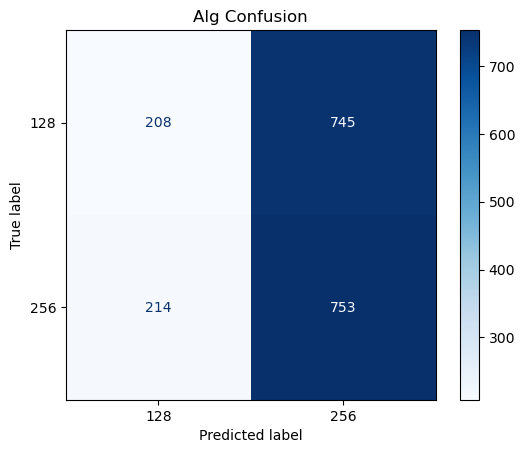

In [57]:
alg_confusion = confusion_matrix(alg_true_label, alg_pred_label, labels=algs)
alg_disp = ConfusionMatrixDisplay(confusion_matrix=alg_confusion, display_labels=algs)
alg_disp.plot(cmap="Blues", values_format = 'd')
plt.title("Alg Confusion")
plt.show()

In [58]:
pass_probs128 = pass_classifier128.predict(pass128_test_x)
pass_preds128 = np.array([np.argmax(prob) for prob in pass_probs128])
print(pass_preds128)
print(enum_pass_test_targets128)
pass_inv_mapping = {idx: label for label, idx in pass_mapping.items()}
pass_true_label128 = [pass_inv_mapping[idx] for idx in enum_pass_test_targets128['password'].to_list()]
pass_pred_label128 = [pass_inv_mapping[idk] for idk in pass_preds128]

pass_probs256 = pass_classifier256.predict(pass256_test_x)
pass_preds256 = np.array([np.argmax(prob) for prob in pass_probs256])
print(pass_preds256)
print(enum_pass_test_targets256)
pass_true_label256 = [pass_inv_mapping[idx] for idx in enum_pass_test_targets256['password'].to_list()]
pass_pred_label256 = [pass_inv_mapping[idk] for idk in pass_preds256]

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.



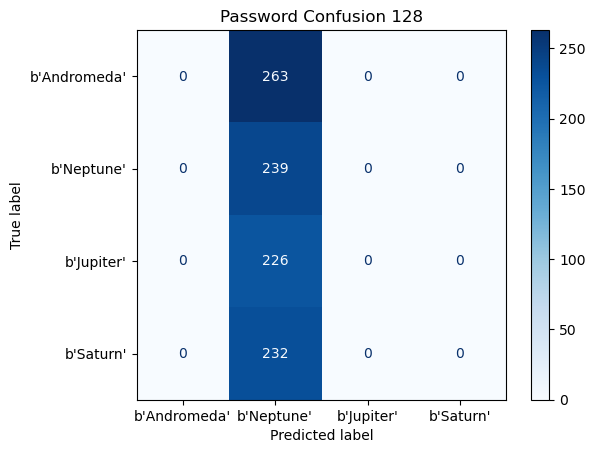

In [59]:
pass_confusion128 = confusion_matrix(pass_true_label128, pass_pred_label128, labels=passwords)
pass_disp128 = ConfusionMatrixDisplay(confusion_matrix=pass_confusion128, display_labels=passwords)
pass_disp128.plot(cmap="Blues", values_format = 'd')
plt.title("Password Confusion 128")
plt.show()

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.

/home/andromeda/anaconda3/envs/cryptography/lib/python3.12/site-packages/sklearn/utils/multiclass.py:367: FutureWarning:

Support for labels represented as bytes is deprecated in v1.5 and will error in v1.7. Convert the labels to a string or integer format.



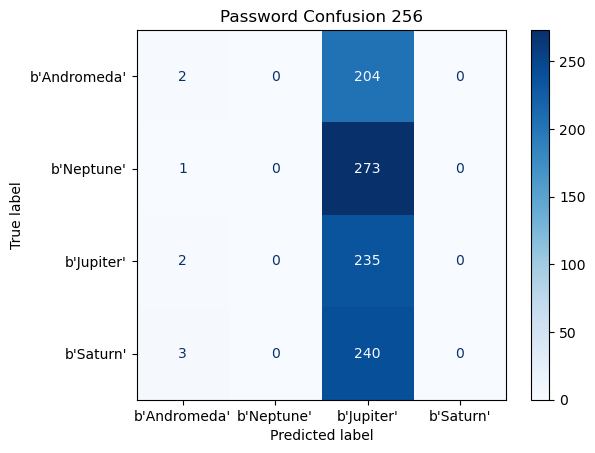

In [60]:
pass_confusion256 = confusion_matrix(pass_true_label256, pass_pred_label256, labels=passwords)
pass_disp256 = ConfusionMatrixDisplay(confusion_matrix=pass_confusion256, display_labels=passwords)
pass_disp256.plot(cmap="Blues", values_format = 'd')
plt.title("Password Confusion 256")
plt.show()

In [61]:
encoded_data = encoder.predict(np.array(df['ciphertext'].to_list()))

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [62]:
alg_true, alg_map = make_mapping(df, algs, 'alg')
# print(encoded_data[:, 0])
# print(len(encoded_data[:, 0]))
# print(len(encoded_data[:, 1]))
# print(len(encoded_data[:, 2]))
# print(len(alg_true))
# print(len(sc_alg_pred))
# print(alg_true.shape)
# print(sc_alg_pred.shape)
alg_true = alg_true['alg']
# print(np.unique(sc_alg_pred, return_counts = True))

In [66]:
alg_cluster_results = pd.DataFrame({
    'X1': encoded_data[:, 0],
    'X2': encoded_data[:, 1],
    'X3': encoded_data[:, 2],
    'True Label': alg_true
    #'Predicted Cluster': sc_alg_pred
})

fig_true = px.scatter_3d(
    alg_cluster_results, x='X1', y='X2', z='X3',
    color='True Label',
    title='Alg True Labels in Autoencoded 3D Space'
)
fig_true.show()

# fig_pred = px.scatter_3d(
#     alg_cluster_results, x='X1', y='X2', z='X3',
#     color='Predicted Cluster',
#     title='Spectral Clustering in 3D Latent Space'
# )
# fig_pred.show()


In [67]:
pass_true, pass_map = make_mapping(df, passwords, 'password')
# print(encoded_data[:, 0])
# print(len(encoded_data[:, 0]))
# print(len(encoded_data[:, 1]))
# print(len(encoded_data[:, 2]))
# print(len(alg_true))
# print(len(sc_pass_pred))
# print(pass_true.shape)
# print(sc_pass_pred.shape)
pass_true = pass_true['password']
# print(np.unique(sc_pass_pred, return_counts = True))

In [68]:
alg_cluster_results = pd.DataFrame({
    'X1': encoded_data[:, 0],
    'X2': encoded_data[:, 1],
    'X3': encoded_data[:, 2],
    'True Label': pass_true
    #'Predicted Cluster': sc_pass_pred
})

fig_true = px.scatter_3d(
    alg_cluster_results, x='X1', y='X2', z='X3',
    color='True Label',
    title='Password True Labels in Autoencoded 3D Space'
)
fig_true.show()

# fig_pred = px.scatter_3d(
#     alg_cluster_results, x='X1', y='X2', z='X3',
#     color='Predicted Cluster',
#     title='Spectral Clustering in 3D Latent Space'
# )
# fig_pred.show()


In [69]:
alg_probs = alg_classifier.predict(test_data_format)
alg_preds = np.array([np.argmax(prob) for prob in alg_probs])
print(alg_preds)
print(enum_alg_test_targets)
alg_inv_mapping = {idx: label for label, idx in alg_mapping.items()}
alg_true_label = [alg_inv_mapping[idx] for idx in enum_alg_test_targets['alg'].to_list()]
alg_pred_label = [alg_inv_mapping[idk] for idk in alg_preds]

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[1 1 0 ... 1 1 1]
shape: (1_920, 4)
┌─────┬──────────────┬───────────────────┬─────────────────────────────────┐
│ alg ┆ password     ┆ source_file       ┆ plaintext                       │
│ --- ┆ ---          ┆ ---               ┆ ---                             │
│ i64 ┆ binary       ┆ str               ┆ binary                          │
╞═════╪══════════════╪═══════════════════╪═════════════════════════════════╡
│ 0   ┆ b"Saturn"    ┆ Convo15Message1_5 ┆ b"Expect\x20a\x20surge\x20in\x… │
│ 1   ┆ b"Neptune"   ┆ Convo23Message3_3 ┆ b"ng\x20a\x20full-scale\x20ala… │
│ 1   ┆ b"Andromeda" ┆ Convo37Message2_7 ┆ b"\xe2\x80\x99m\x20transmittin… │
│ 0   ┆ b"Jupiter"   ┆ Convo8Message3_2  ┆ b"ything.\x20Authorization\x20… │
│ 1   ┆ b"Neptune"   ┆ Convo34Message2_0 ┆ b"Subject:\x20Kepler\x20-\x20N… │
│ …   ┆ …            ┆ …                 ┆ …                               │
│ 1   ┆ b"Saturn"    ┆ Convo20Message1_2 ┆ b"s.\x20The\x20\xe2\x80\x98Tem… │
│

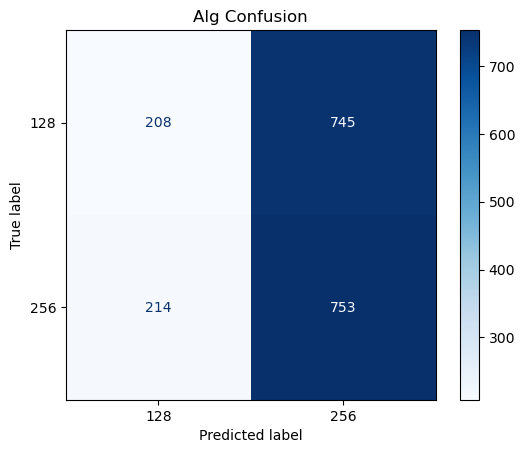

In [70]:
alg_confusion = confusion_matrix(alg_true_label, alg_pred_label, labels=algs)
alg_disp = ConfusionMatrixDisplay(confusion_matrix=alg_confusion, display_labels=algs)
alg_disp.plot(cmap="Blues", values_format = 'd')
plt.title("Alg Confusion")
plt.show()